In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix,classification_report


In [2]:

base_model = EfficientNetV2B0(
    weights='imagenet', 
    input_shape=(128, 128, 3), 
    include_top=False
)

base_model.trainable = False

In [3]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Replacing Flatten() with GlobalAveragePooling2D for better efficiency
    layers.BatchNormalization(),     
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),              
    layers.Dense(38, activation='softmax') 
])

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'D:\\Plant Disease Classifier\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'D:\\Plant Disease Classifier\\New Plant Diseases Dataset(Augmented)\\New Plant Diseases Dataset(Augmented)\\valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)



Found 17572 files belonging to 38 classes.


In [6]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [7]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[138.   140.   161.  ]
   [135.   137.   158.  ]
   [131.75 133.75 154.75]
   ...
   [133.5  128.5  148.5 ]
   [133.   128.   148.  ]
   [131.   126.   146.  ]]

  [[133.5  135.5  156.5 ]
   [132.5  134.5  155.5 ]
   [136.5  138.5  159.5 ]
   ...
   [112.75 107.75 127.75]
   [130.75 125.75 145.75]
   [132.25 127.25 147.25]]

  [[135.75 137.75 158.75]
   [141.   143.   164.  ]
   [140.5  142.5  163.5 ]
   ...
   [161.25 156.25 176.25]
   [132.75 127.75 147.75]
   [124.75 119.75 139.75]]

  ...

  [[175.25 177.25 190.25]
   [179.25 181.25 194.25]
   [184.25 186.25 199.25]
   ...
   [161.75 159.75 170.75]
   [179.75 177.75 188.75]
   [172.75 170.75 181.75]]

  [[179.25 181.25 194.25]
   [179.75 181.75 194.75]
   [186.5  188.5  201.5 ]
   ...
   [165.25 163.25 174.25]
   [165.5  163.5  174.5 ]
   [174.5  172.5  183.5 ]]

  [[170.5  172.5  185.5 ]
   [169.25 171.25 184.25]
   [181.75 183.75 196.75]
   ...
   [164.   162.   173.  ]
   [159.5  157.5  168.5 ]
   [171.25 169.25 18

In [8]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10


2197/2197 [==============================] - 481s 206ms/step - loss: 2.4572 - accuracy: 0.3810 - val_loss: 0.8403 - val_accuracy: 0.8079
Epoch 2/10
2197/2197 [==============================] - 447s 204ms/step - loss: 0.7137 - accuracy: 0.8030 - val_loss: 0.2767 - val_accuracy: 0.9261
Epoch 3/10
2197/2197 [==============================] - 438s 199ms/step - loss: 0.3445 - accuracy: 0.8998 - val_loss: 0.1430 - val_accuracy: 0.9569
Epoch 4/10
2197/2197 [==============================] - 418s 190ms/step - loss: 0.2125 - accuracy: 0.9369 - val_loss: 0.0905 - val_accuracy: 0.9722
Epoch 5/10
2197/2197 [==============================] - 465s 212ms/step - loss: 0.1469 - accuracy: 0.9553 - val_loss: 0.0656 - val_accuracy: 0.9799
Epoch 6/10
2197/2197 [==============================] - 438s 199ms/step - loss: 0.1041 - accuracy: 0.9688 - val_loss: 0.0532 - val_accuracy: 0.9836
Epoch 7/10
2197/2197 [==============================] - 435s 198ms/step - loss: 0.0824 - accuracy: 0.9749 - val_loss: 0.042

In [10]:
# Save the model
model.save('model.keras')
print("Model saved successfully!")

Model saved successfully!


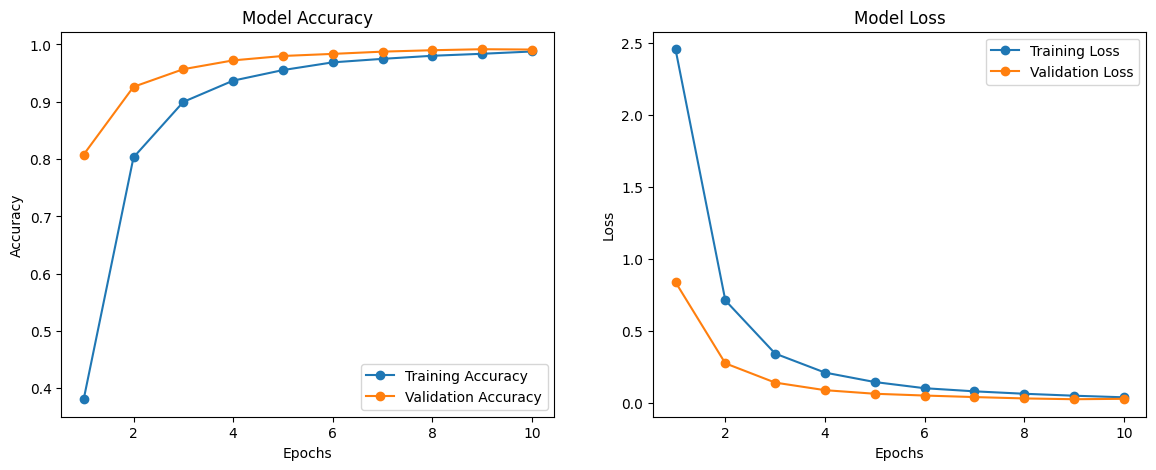

In [ ]:
# Training History Visualization

# 1. Plot Training History
epochs = range(1, len(history.history['accuracy']) + 1)
plt.figure(figsize=(14, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Generating predictions on Validation Set... This might take a minute.


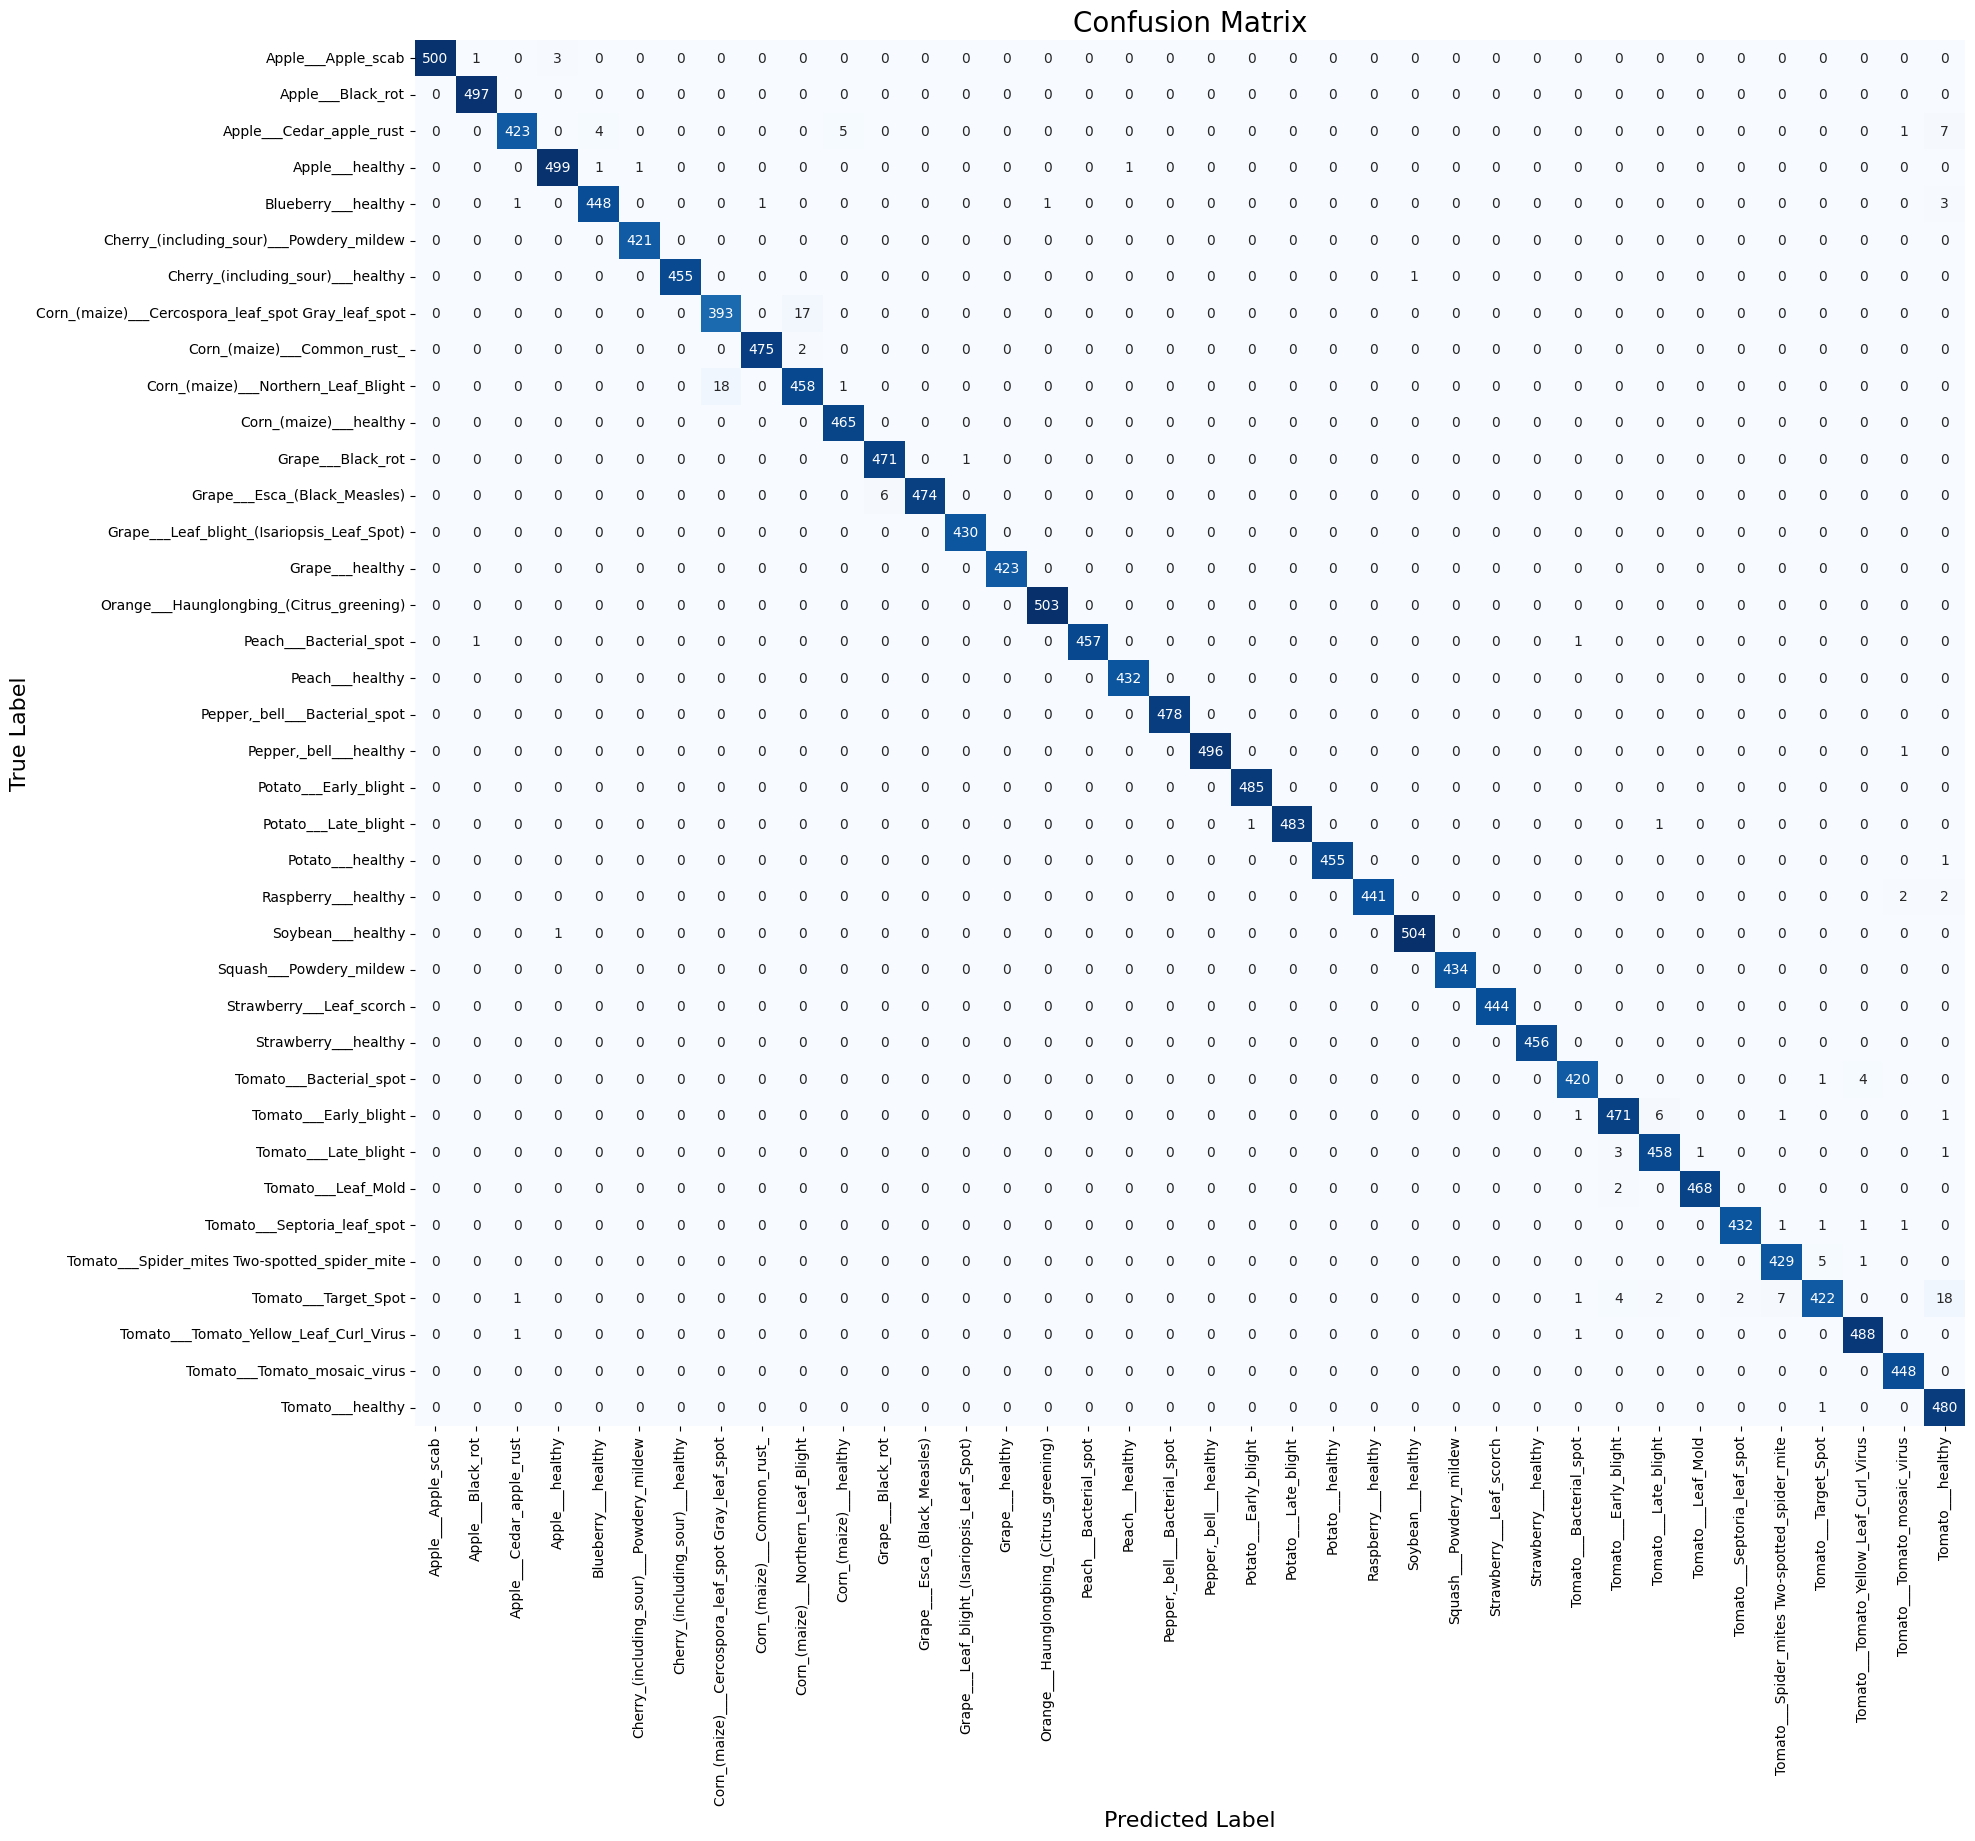


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.99      1.00       504
                                 Apple___Black_rot       1.00      1.00      1.00       497
                          Apple___Cedar_apple_rust       0.99      0.96      0.98       440
                                   Apple___healthy       0.99      0.99      0.99       502
                               Blueberry___healthy       0.99      0.99      0.99       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.96      0.96       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight    

In [ ]:
# extracting the class names from the dataset
class_names = training_set.class_names  
print("Generating predictions on Validation Set... This might take a minute.")
y_true = []
y_pred = []

# Iterating over the validation dataset to get true labels and predictions

for x_batch, y_batch in validation_set:
    #y_batch is one-hot encoded, but the the actual index
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    
    # model predictions for everything in this batch
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)
# Ploting Confusion Matrix
plt.figure(figsize=(20, 18))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False,
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.xticks(rotation=90)
plt.show()

#Classification Report (Precision, Recall, F1-Score per class)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))